In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('amz_uk_price_prediction_dataset.csv')
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [3]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


In [4]:
# Part 1
# 1. Tabla de frecuencias para 'category'
freq_category = df['category'].value_counts()
freq_category

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Alexa Built-In Devices                       107
Motorbike Chassis                            107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

In [5]:
# Top 5
top5 = freq_category.head(5)
print(top5)

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64


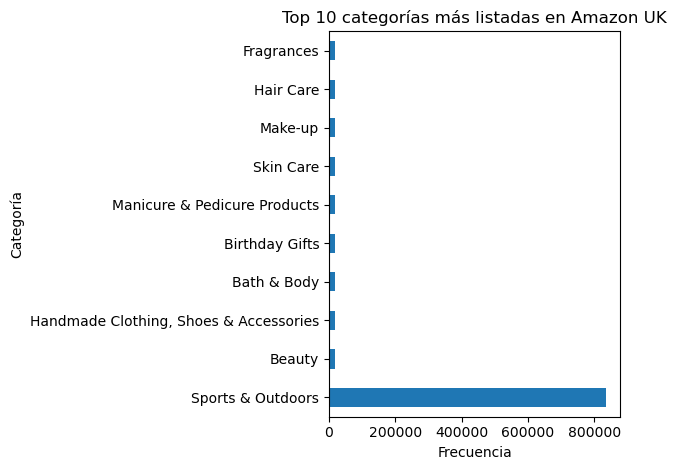

In [27]:
# 2. visualizaciones
# - Bar chart
freq_category.head(10).plot(kind='barh')
plt.title('Top 10 categorías más listadas en Amazon UK')
plt.xlabel('Frecuencia')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()

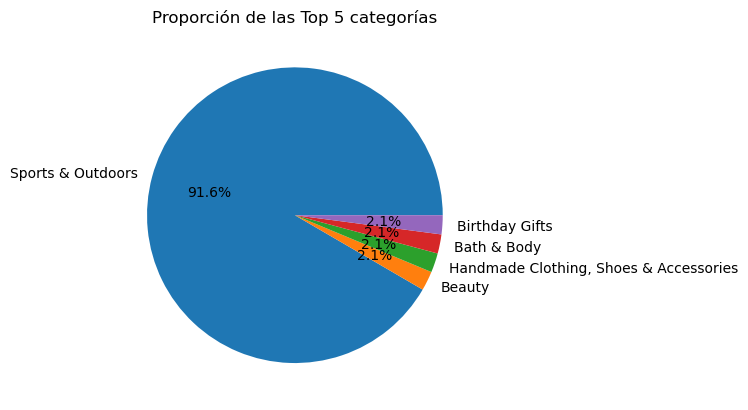

In [37]:
# Pie chart
freq_category.head(5).plot(kind='pie', autopct='%1.1f%%')
plt.title('Proporción de las Top 5 categorías')
plt.ylabel('')  # elimina el label "count" que pandas pone por defecto
plt.show()


**Business Question**: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

Sports & Outdoors domina claramente con un 91.6% de los productos del top 5.

El gráfico de barras confirma visualmente esta dominancia. La barra de Sports & Outdoors  es significativamente más grande que el resto, lo que hace difícil comparar las demás  categorías entre sí. Por eso se ha usado solo el top 10 en vez de todas las categorías, ya que con todas el gráfico no se podría entender.

El pie chart del top 5 deja aún más claro el dominio de Sports & Outdoors con un 91.6% del total. El 8.4% restante se reparte entre las otras 4 categorías, lo que confirma  que el dataset está muy concentrado en una sola categoría y no es representativo de todo Amazon UK.




In [ ]:
# Parte 2
# 1. Measures of Centrality de 'Price'
#   - Calculate the mean, median, and mode for the `price` of products.
mean_price   = df['price'].mean()
median_price = df['price'].median()
mode_price   = df['price'].mode()[0]

print(f"Media:   {mean_price:.2f}")
print(f"Mediana: {median_price:.2f}")
print(f"Moda:    {mode_price:.2f}")


Media:   89.24
Mediana: 19.09
Moda:    9.99


La moda (£9.99) — el precio más común es menos de 10 libras. Productos baratos del día a día.

La mediana (£19.09) — la mitad de los productos cuestan menos de £19. Sigue siendo un precio razonable

La media (£89.24) — el promedio se dispara a £89 


La media en este caso no representa al producto típico. El precio real más común está entre £9.99 y £19, pero unos pocos productos carísimosn  haceb que la media se dispare. Por eso en datasets con outliers la mediana es más fiable que la media.

### - What's the average price point of products listed? How does this compare with the most common price point (mode)?

El precio medio de los productos es £89.24, pero este dato es engañoso porque está arrastrado por productos muy caros. El precio más común (moda) es £9.99, lo que indica que la mayoría de productos son bastante económicos. 

La diferencia tan grande entre media y moda confirma que hay outliers de precios muy altos que distorsionan el promedio.

In [42]:
# 2. Measures of Dispersion
# - Determine the variance, standard deviation, range, and interquartile range for product `price`.
var = df['price'].var()
des = df['price'].std()
rang = df['price'].max() - df['price'].min()
rango_intercuartil = df['price'].quantile(0.75) - df['price'].quantile(0.25)

print(f"Varianza:           {varianza:.2f}")
print(f"Desviación típica:  {desviacion:.2f}")
print(f"Rango:              {rango:.2f}")
print(f"Rango intercuartil: {rango_intercuartil:.2f}")

Varianza:           119445.49
Desviación típica:  345.61
Rango:              100000.00
Rango intercuartil: 36.00


Varianza: 119,445.49

Número muy alto pero difícil de interpretar porque está en £² (libras al cuadrado). Por eso miramos la desviación típica.

Desviación típica: £345.61

El precio medio se desvía ±£345 — es una barbaridad. Indica que hay productos muy baratos y muy caros mezclados.

Rango: £100,000 El producto más barato y el más caro tienen una diferencia de 100,000 libras. Hay algún producto extremadamente caro que dispara este valor.

Rango intercuartil: £36 dato clave — el 50% central de los productos tiene solo £36 de diferencia entre sí. Esto significa que la mayoría de productos son baratos y están muy concentrados en un rango estrecho de precio, pero hay unos pocos productos extremadamente caros que distorsionan completamente la media y la desviación típica.

### - How varied are the product prices? Are there any indicators of a significant spread in prices?

Los precios están muy dispersos. La desviación típica de £345.61 indica que los precios se alejan mucho del promedio, y el rango de £100,000 entre el producto más barato y el más caro confirma que hay productos extremadamente caros en el dataset.

Sin embargo, el rango intercuartil de solo £36 nos dice que el 50% central de los productos tiene precios muy concentrados y económicos. Esto indica que la gran dispersión no es general, sino causada por unos pocos productos muy caros que actúan como outliers.

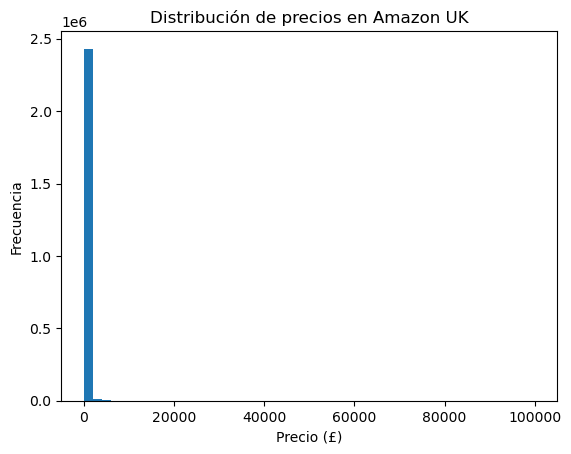

In [54]:
# 3. Visualizations
# - Histogram de product prices. Is there a specific price range where most products fall?  
# If its hard to read these diagrams, think why this is, and explain how it could be solved
df['price'].plot(kind='hist', bins=50)
plt.title('Distribución de precios en Amazon UK')
plt.xlabel('Precio (£)')
plt.ylabel('Frecuencia')
plt.show()


Se ha puesto bins=50 para que divida los precios en 50 rangos para ver mejor dónde se concentran. Sin embargo solo se ve una barra y unas barras adicionales que casi no se pueden viaulizar.

Esto pasa porque los outliers (productos de £100,000) obligan al eje X a estirarse hasta £100,000, pero el 99% de los productos están entre £0 y £100. Entonces todas las barras se amontonan en la izquierda y casi no se ven.

Solución? Filtrando los outliers para visualizar solo el rango donde está la mayoría de productos

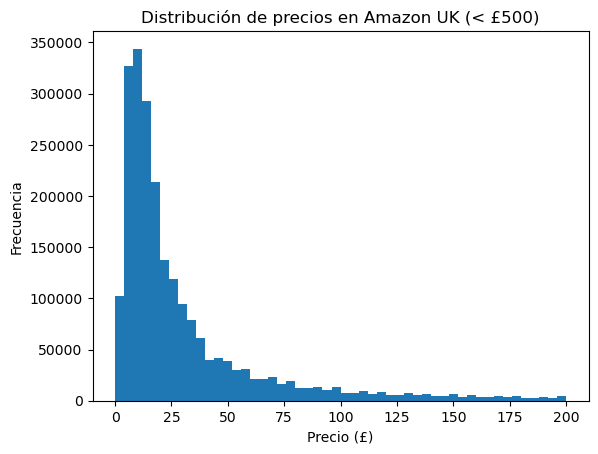

In [ ]:
df[df['price'] < 200]['price'].plot(kind='hist', bins=50)
plt.title('Distribución de precios en Amazon UK (< £200)')
plt.xlabel('Precio (£)')
plt.ylabel('Frecuencia')
plt.show()

Se pone menores de 200 pounds porque el IQR era £36 y la mediana £19, así que sabemos que la gran mayoría de productos están por debajo de £200.
- El pico está entre £5 y £15 — ahí está la mayoría de productos, con más de 350,000
- A partir de £25 cae drásticamente y sigue bajando
- Hay una cola larga hacia la derecha — cada vez menos productos conforme sube el precio

Muchos productos baratos y pocos caros.

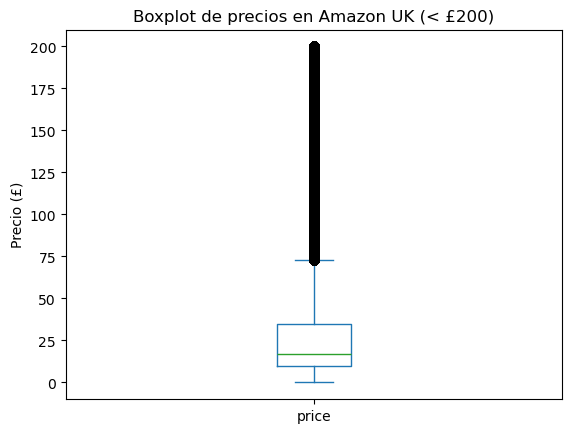

In [ ]:
# Box plot
# - Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing. 
df[df['price'] < 200]['price'].plot(kind='box')
plt.title('Boxplot de precios en Amazon UK (< £200)')
plt.ylabel('Precio (£)')
plt.show()

Insight:

Línea verde → mediana £19
Caja azul → el 50% central de productos está entre £5 y £35 (el IQR de £36 que se calculó)
Bigotes → llegan hasta £75
Barra negra → outliers, productos de £75 a £200

La mayoría de productos son baratos y hay muchísimos outliers hacia precios altos.

In [11]:
# Part 3
# 1. Measures of Centrality:
# - Calculate the mean, median, and mode for the `rating` of products
df_con_rating = df[df['stars'] != 0.0]

media_rating   = df_con_rating['stars'].mean()
mediana_rating = df_con_rating['stars'].median()
moda_rating    = df_con_rating['stars'].mode()[0]

print(f"Media:   {media_rating:.2f}")
print(f"Mediana: {mediana_rating:.2f}")
print(f"Moda:    {moda_rating:.2f}")


Media:   4.32
Mediana: 4.40
Moda:    4.50


In [7]:
df['stars'].value_counts().head(3)

stars
0.0    1225641
4.5     151577
4.6     136995
Name: count, dtype: int64

In [10]:
print(df.shape)
print(df['stars'].value_counts()[0.0])

(2443651, 9)
1225641


In [68]:
print(df['stars'].value_counts()[0])
print(f"Porcentaje sin valoración: {(df['stars'] == 0).mean() * 100:.1f}%")

1225641
Porcentaje sin valoración: 50.2%


Insight medidas de centralidad:
- Media: 4.32 — en promedio los productos están muy bien valorados, por encima de 4 estrellas.
- Mediana: 4.40 — la mitad de los productos tienen 4.4 o más estrellas. Los clientes tienden a valorar positivamente.
- Moda: 4.50 — la valoración más común es 4.5 estrellas.

Las tres medidas están muy juntas (4.32, 4.40, 4.50) lo que indica una distribución bastante simétrica y concentrada en valoraciones altas. Los clientes de Amazon UK tienden a dejar valoraciones positivas.

In [12]:
# 2. Measures of Dispersion:
#   - Determine the variance, standard deviation, and interquartile range for product `rating`
#   - Are the ratings consistent, or is there a wide variation in customer feedback?

varianza_rating           = df_con_rating['stars'].var()
desviacion_rating         = df_con_rating['stars'].std()
rango_intercuartil_rating = df_con_rating['stars'].quantile(0.75) - df_con_rating['stars'].quantile(0.25)

print(f"Varianza:           {varianza_rating:.2f}")
print(f"Desviación típica:  {desviacion_rating:.2f}")
print(f"Rango intercuartil: {rango_intercuartil_rating:.2f}")


Varianza:           0.31
Desviación típica:  0.56
Rango intercuartil: 0.50


Insight medidas de dispersión:
- Varianza: 0.31 y Desviación típica: 0.56
Las valoraciones se desvían solo 0.56 estrellas respecto a la media. En una escala del 1 al 5 es muy poco — los clientes son bastante consistentes en sus valoraciones.
- Rango intercuartil: 0.50
El 50% central de los productos tiene valoraciones entre 4.1 y 4.6 estrellas. Rango muy estrecho, confirma que las valoraciones están muy concentradas en valores altos

In [13]:
# 3. Shape of the Distribution:
#   - Calculate the skewness and kurtosis for the `rating` column. 
#   - Are the ratings normally distributed, or do they lean towards higher or lower values?

sesgo    = df_con_rating['stars'].skew()
curtosis = df_con_rating['stars'].kurt()

print(f"Sesgo:    {sesgo:.2f}")
print(f"Curtosis: {curtosis:.2f}")

Sesgo:    -2.38
Curtosis: 9.78


Insight forma de distribución:

Sesgo: -2.38
Sesgo negativo — la cola está hacia la izquierda (valoraciones bajas). La mayoría de productos se concentran en valoraciones altas y hay pocos productos mal valorados. Confirma el sesgo de valoración positiva.

Curtosis: 9.78
Valor muy alto — significa que la distribución tiene un pico muy pronunciado alrededor de 4.5 estrellas. No es una distribución normal, sino muy apuntada en los valores altos.


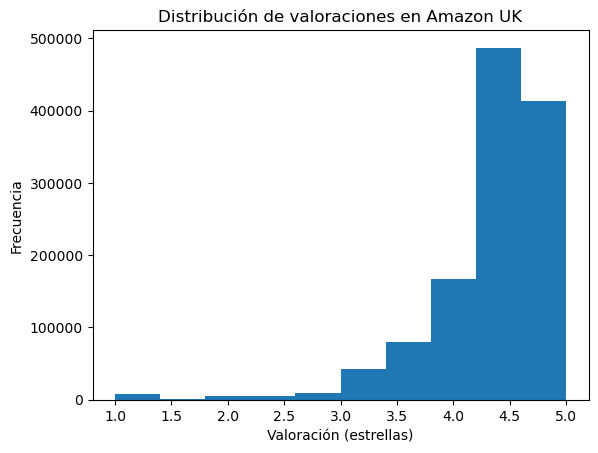

In [15]:
# 4. Visualizations*
#   - Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

df_con_rating['stars'].plot(kind='hist')
plt.title('Distribución de valoraciones en Amazon UK')
plt.xlabel('Valoración (estrellas)')
plt.ylabel('Frecuencia')
plt.show()

Insight histograma:
- Las barras más altas están entre 4.5 y 5 estrellas — ahí se concentra la mayoría de productos
- A partir de 4.0 hacia abajo las barras caen drásticamente
- Hay muy pocos productos con valoraciones bajas (1, 1.5, 2 estrellas)
- La cola hacia la izquierda confirma el sesgo negativo de -2.38 que se ha calculado anteriormente

**Part 3: Unpacking Product Ratings**

**Business Question**: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

Nota previa:

El 50.2% de los productos no tenían valoración (0 estrellas). Estos se han filtrado antes del análisis para no distorsionar los resultados.

**Medidas de centralidad**

Media (4.32), mediana (4.40) y moda (4.50) están muy juntas y en valores altos, lo que indica que los clientes tienden a valorar positivamente los productos. La valoración más común es 4.5 estrellas.

**Medidas de dispersión**
La desviación típica de solo 0.56 y el rango intercuartil de 0.50 indican que las valoraciones son muy consistentes y están concentradas entre 4.1 y 4.6 estrellas. Hay muy poca variación en el feedback de los clientes.

**Forma de la distribución**

El sesgo negativo (-2.38) confirma que la cola está hacia valoraciones bajas — la mayoría de productos se concentran en valores altos. 

La curtosis de 9.78 indica un pico muy pronunciado alrededor de 4.5 estrellas, lo que significa que la distribución no es normal sino muy apuntada.

**Histograma**

El histograma confirma visualmente todo lo anterior — las barras más altas están entre 4.5 y 5 estrellas y luego caen hacia valoraciones bajas. 

